# 14 — Cobertura de intervalos: evaluación probabilística

**RESPIR-AI · TFG** — Además del MAE: ¿qué porcentaje de los valores reales queda dentro de los
intervalos de predicción de cada modelo? Se evalúan los intervalos **[q25, q75]** (nominal 50 %) y
**[q10, q90]** (nominal 80 %) sobre las 36 ventanas del protocolo v2, con dos vías por familia:

- **Nativa**: cuantiles de Chronos-2 (`predict_quantiles`), regresión cuantílica de XGBoost
  (`reg:quantileerror`, directa por paso). TTM no ofrece cuantiles nativos (cabeza puntual con
  `loss='mse'`; el campo `distribution_output='student_t'` de la config es un valor por defecto sin
  cabeza activa) — se documenta y se usa solo la vía conformal.
- **Conformal split**: cuantiles empíricos de los residuos absolutos por horizonte en el split de
  **validación** (23 orígenes del cuaderno 13) → intervalos simétricos alrededor de la predicción
  puntual. Aplicado a todas las familias, incluida Chronos-2 (¿están calibrados los cuantiles
  nativos del fundacional en este dominio?).

Métricas: cobertura empírica (agregada en h≤H y por paso), anchura media (absoluta y % de la media
de la señal, 24.4 mg O₂/L·h), interval score (Winkler), CRPS aproximado para Chronos-2, cobertura
condicional (día/noche, mes) y cobertura estacional sobre las 188 ventanas de bloques.

In [1]:
# Raíz del repositorio como cwd
import os, sys
from pathlib import Path
ROOT = Path.cwd() if (Path.cwd()/"common_eval.py").exists() else Path.cwd().parent
os.chdir(ROOT); sys.path.insert(0, str(ROOT))

import time, warnings, json, itertools
import numpy as np, pandas as pd, torch
from xgboost import XGBRegressor
from skforecast.recursive import ForecasterRecursiveMultiSeries
from chronos import Chronos2Pipeline
from tsfm_public.models.tinytimemixer import TinyTimeMixerForPrediction
from scipy import stats
warnings.filterwarnings("ignore")
from common_eval import *
import common_eval as CE

df, proto = load_all()
origins = get_origins(df, proto)
Y = true_targets(df, origins)
test_ilocs = [o['iloc'] for o in origins]
seg = df.segment_id.to_numpy()
seg_s = pd.Series(seg, index=df.index)
train_end = proto['particion']['train']['fin']
val_start = proto['particion']['val']['inicio']
val_end   = proto['particion']['val']['fin']
y_masked = df['our'].where(df.segment_id >= 0)
MEDIA_SENAL = 24.4
QL = [0.10, 0.25, 0.50, 0.75, 0.90]          # niveles de cuantil
NIVELES = {50: (1, 3), 80: (0, 4)}            # nominal -> (índice q_lo, q_hi) en QL

# orígenes de validación (los 23 del cuaderno 13)
val_mask = (df.index >= val_start) & (df.index <= val_end)
val_ilocs, last = [], -10**9
for i in np.where(val_mask)[0]:
    s = seg[i]
    if s < 0 or i - last < 24: continue
    if i-511 < 0 or (seg[i-511:i+1] != s).any(): continue
    if i+48 >= len(df) or (seg[i+1:i+49] != s).any(): continue
    if not df.index[i+48] <= pd.Timestamp(val_end): continue
    val_ilocs.append(i); last = i
Y_val = np.stack([df['our'].iloc[i+1:i+49].to_numpy() for i in val_ilocs])

def interval_score(y, lo, hi, nominal):
    """Winkler score; nominal en {50, 80} -> alpha = 1 - nominal/100."""
    a = 1 - nominal/100
    return (hi - lo) + (2/a)*np.maximum(lo - y, 0) + (2/a)*np.maximum(y - hi, 0)

def pinball(y, q, tau):
    d = y - q
    return np.maximum(tau*d, (tau-1)*d)

print(f"test: {len(test_ilocs)} ventanas | val: {len(val_ilocs)} | niveles: {QL}")

test: 36 ventanas | val: 23 | niveles: [0.1, 0.25, 0.5, 0.75, 0.9]


## 1. Cuantiles nativos de Chronos-2 (test y validación)

Configuraciones: F con C=1024 (la elegida en validación, contexto NaN-relleno), F y U con C=512,
F con C=128, y el **ensemble de contextos {128, 512, 1024}** (promedio de cuantiles, el trío elegido
en validación en el cuaderno 13). La validación se predice también para la vía conformal.

In [2]:
pipe = Chronos2Pipeline.from_pretrained("amazon/chronos-2", device_map="cuda")
torch.manual_seed(42); np.random.seed(42)

def c2_ctx(ilocs, C, with_f):
    nanfill = C > 512
    dicts = []
    for i in ilocs:
        lo = max(0, i - C + 1)
        tgt = (y_masked if nanfill else df['our']).iloc[lo:i+1].to_numpy(dtype=np.float32)
        d = {"target": tgt}
        if with_f:
            d["past_covariates"] = {c: df[c].iloc[lo:i+1].to_numpy(dtype=np.float32) for c in METEO}
            d["future_covariates"] = {c: df[c].iloc[i+1:i+49].to_numpy(dtype=np.float32) for c in METEO}
        dicts.append(d)
    return dicts

def c2_quant(ilocs, C, with_f):
    """-> (n, 48, 5) cuantiles nativos."""
    q, _ = pipe.predict_quantiles(c2_ctx(ilocs, C, with_f), prediction_length=48, quantile_levels=QL)
    return np.stack([t.squeeze(0).numpy() if t.ndim==3 else t.numpy() for t in q]).astype(float)

QT, QV = {}, {}   # config -> (n,48,5) en test / validación
for nombre, C, wf in [("c2_F_C1024", 1024, True), ("c2_F_C512", 512, True),
                      ("c2_U_C512", 512, False), ("c2_F_C128", 128, True)]:
    QT[nombre] = c2_quant(test_ilocs, C, wf)
    QV[nombre] = c2_quant(val_ilocs, C, wf)
# ensemble de contextos (trío elegido en validación, cuaderno 13): promedio de cuantiles
QT["c2_ens_ctx_F"] = np.mean([QT[k] for k in ("c2_F_C128", "c2_F_C512", "c2_F_C1024")], axis=0)
QV["c2_ens_ctx_F"] = np.mean([QV[k] for k in ("c2_F_C128", "c2_F_C512", "c2_F_C1024")], axis=0)
del pipe; torch.cuda.empty_cache()
for k, v in QT.items():
    cob80 = float(((Y >= v[:,:,0]) & (Y <= v[:,:,4])).mean()*100)
    print(f"{k}: cobertura 80% (todos los pasos): {cob80:.1f}%")

c2_F_C1024: cobertura 80% (todos los pasos): 74.5%
c2_F_C512: cobertura 80% (todos los pasos): 70.4%
c2_U_C512: cobertura 80% (todos los pasos): 67.7%
c2_F_C128: cobertura 80% (todos los pasos): 75.9%
c2_ens_ctx_F: cobertura 80% (todos los pasos): 75.6%


Loading weights: 100%|##########| 170/170 [00:00<00:00, 2135.08it/s]


## 2. Regresión cuantílica nativa de XGBoost (directa por paso)

`objective='reg:quantileerror'` con los 5 niveles en un solo modelo por paso h (XGBoost ≥ 2.0
garantiza monotonía entre cuantiles). Estrategia **directa por h** — más limpia para cuantiles que
la recursiva, que necesitaría propagar la mediana y re-estimar la incertidumbre; se documenta la
diferencia con el E1/E3 recursivo puntual de los cuadernos 03/11. Features: retardos 1–48 (E1) +
meteo real de la hora objetivo (E3). Entrenamiento con train+val (la vía nativa no necesita
calibración posterior).

In [3]:
FEAT = pd.DataFrame({f"lag{j}": y_masked.shift(j-1) for j in range(1, 49)}, index=df.index)
meteo_full = df[METEO].astype(float)
HPQ = dict(learning_rate=0.05, max_depth=4, n_estimators=300, random_state=42, n_jobs=8)

def xgb_quant_direct(use_meteo, end_ts, pred_ilocs):
    out = np.full((len(pred_ilocs), 48, 5), np.nan)
    for h in range(1, 49):
        tgt = y_masked.shift(-h)
        ok = (df.index <= pd.Timestamp(end_ts)) & tgt.notna() & (seg_s.shift(-h)==seg_s) & (seg>=0)
        X = FEAT[ok]
        if use_meteo:
            X = pd.concat([X, meteo_full.shift(-h)[ok].add_suffix("_fut")], axis=1)
        m = XGBRegressor(objective="reg:quantileerror", quantile_alpha=np.array(QL), **HPQ)
        m.fit(X, tgt[ok])
        Xp = FEAT.iloc[pred_ilocs]
        if use_meteo:
            Xp = pd.concat([Xp, meteo_full.shift(-h).iloc[pred_ilocs].add_suffix("_fut")], axis=1)
        out[:, h-1, :] = m.predict(Xp)
    return np.sort(out, axis=2)   # garantía extra de monotonía

t0 = time.perf_counter()
QT["xgb_E1"] = xgb_quant_direct(False, val_end, test_ilocs)
QT["xgb_E3"] = xgb_quant_direct(True, val_end, test_ilocs)
print(f"XGBoost cuantílico directo: {time.perf_counter()-t0:.0f} s")
for k in ("xgb_E1", "xgb_E3"):
    cob80 = float(((Y >= QT[k][:,:,0]) & (Y <= QT[k][:,:,4])).mean()*100)
    print(f"{k} nativa: cobertura 80%: {cob80:.1f}%")

XGBoost cuantílico directo: 651 s
xgb_E1 nativa: cobertura 80%: 68.6%
xgb_E3 nativa: cobertura 80%: 69.3%


## 3. Predicciones puntuales para la vía conformal

Split-conformal limpio: el MISMO modelo (entrenado solo con train) genera los residuos de validación
y las predicciones de test. XGBoost E1/E3 recursivos (48 lags, hiperparámetros del cuaderno 03);
TTM ZS U y TTM ft5 F (semilla 42, mismo pipeline de los cuadernos 05/13 — con la salvedad de
inestabilidad entre semillas documentada en el 13); Chronos-2: la mediana nativa (q50) hace de
predicción puntual.

In [4]:
y_asf = y_masked.asfreq('h'); meteo_asf = df[METEO].astype(float).asfreq('h')
HP03 = dict(learning_rate=0.05, max_depth=4, n_estimators=300)
PT, PV = {}, {}   # puntual test / val

for use_exog, tag in [(False, "xgb_E1"), (True, "xgb_E3")]:
    f = ForecasterRecursiveMultiSeries(
        estimator=XGBRegressor(**HP03, random_state=42, n_jobs=8, objective="reg:squarederror"),
        lags=48, encoding=None, dropna_from_series=True)
    f.fit(series=pd.DataFrame({"our": y_asf.loc[:train_end]}),
          exog=meteo_asf.loc[:train_end] if use_exog else None)
    def pred(ilocs):
        out = []
        for i in ilocs:
            lw = pd.DataFrame({"our": df['our'].iloc[i-47:i+1]}).asfreq('h')
            ex = meteo_asf.iloc[i+1:i+49] if use_exog else None
            out.append(f.predict(steps=48, last_window=lw, exog=ex, levels="our")['pred'].to_numpy())
        return np.stack(out)
    PT[tag] = pred(test_ilocs); PV[tag] = pred(val_ilocs)
print("XGBoost puntual (train-only) hecho")

# TTM ZS U y ft5 F
DEV = "cuda"
CHANNELS = ['our'] + PROC + METEO
Xall = df[CHANNELS].to_numpy(dtype=np.float32)
meteo_idx = [CHANNELS.index(c) for c in METEO]
cols_F = [0] + meteo_idx
ex_idx = [cols_F.index(ci) for ci in meteo_idx]

def ttm_pred(model, ilocs, cols, use_fut):
    pasts = np.stack([Xall[i-511:i+1][:, cols] for i in ilocs])
    fut = None
    if use_fut:
        fz = np.zeros((len(ilocs), 96, len(cols)), dtype=np.float32)
        for w, i in enumerate(ilocs):
            n = min(96, len(df) - (i+1))
            for k_, ci in enumerate(cols):
                if ci in meteo_idx: fz[w, :n, k_] = Xall[i+1:i+1+n, ci]
        fut = torch.tensor(fz)
    with torch.no_grad():
        out = model(past_values=torch.tensor(pasts).to(DEV),
                    future_values=fut.to(DEV) if fut is not None else None, return_loss=False)
    return out.prediction_outputs[..., 0].float().cpu().numpy()[:, :48]

ttm_u = TinyTimeMixerForPrediction.from_pretrained("ibm-granite/granite-timeseries-ttm-r2").to(DEV).eval()
PT["ttm_zs_U"] = ttm_pred(ttm_u, test_ilocs, [0], False)
PV["ttm_zs_U"] = ttm_pred(ttm_u, val_ilocs, [0], False)
del ttm_u; torch.cuda.empty_cache()

# ft5 F (semilla 42; entrenado con train, early stopping en val — la validación se reutiliza
# para el conformal: peso ligeramente optimista, documentado)
def contiguous_series(mask):
    return [g for _, g in df[mask & (df.segment_id >= 0)].groupby('segment_id')]
tr_chunks = contiguous_series(df.index <= pd.Timestamp(train_end))
va_chunks = contiguous_series((df.index >= pd.Timestamp(val_start)) & (df.index <= pd.Timestamp(val_end)))
WIN = 512 + 96
def window_starts(chunks):
    starts = []
    for g in chunks:
        i0 = df.index.get_loc(g.index[0])
        starts.extend(range(i0, i0 + len(g) - WIN + 1))
    return np.array(starts)
tr_all = window_starts(tr_chunks); va_starts = window_starts(va_chunks)[::4]
def make_tensors(starts, cols):
    past = np.stack([Xall[s:s+512][:, cols] for s in starts])
    fut  = np.stack([Xall[s+512:s+608][:, cols] for s in starts])
    return torch.tensor(past), torch.tensor(fut)
rng = np.random.default_rng(42)
tr5 = rng.choice(tr_all, size=max(1, int(0.05*len(tr_all))), replace=False)
mft = TinyTimeMixerForPrediction.from_pretrained(
    "ibm-granite/granite-timeseries-ttm-r2", num_input_channels=len(cols_F),
    decoder_mode="mix_channel", prediction_channel_indices=[0],
    exogenous_channel_indices=ex_idx, enable_forecast_channel_mixing=True,
    fcm_context_length=5, fcm_use_mixer=True, fcm_prepend_past=True,
    ignore_mismatched_sizes=True).to(DEV)
torch.manual_seed(42)
Xtr, Ytr = make_tensors(tr5, cols_F); Xva, Yva = make_tensors(va_starts, cols_F)
opt = torch.optim.AdamW(mft.parameters(), lr=1e-4)
best, best_state, bad = np.inf, None, 0
for ep in range(50):
    mft.train()
    perm = torch.randperm(Xtr.shape[0])
    for k in range(0, Xtr.shape[0], 64):
        idx = perm[k:k+64]
        out = mft(past_values=Xtr[idx].to(DEV), future_values=Ytr[idx].to(DEV), return_loss=True)
        opt.zero_grad(); out.loss.backward(); opt.step()
    mft.eval()
    with torch.no_grad():
        vl = float(mft(past_values=Xva.to(DEV), future_values=Yva.to(DEV), return_loss=True).loss)
    if vl < best - 1e-5: best, bad, best_state = vl, 0, {k: v.detach().clone() for k, v in mft.state_dict().items()}
    else:
        bad += 1
        if bad >= 5: break
mft.load_state_dict(best_state); mft.eval()
PT["ttm_ft5_F"] = ttm_pred(mft, test_ilocs, cols_F, True)
PV["ttm_ft5_F"] = ttm_pred(mft, val_ilocs, cols_F, True)
del mft; torch.cuda.empty_cache()

# Chronos-2: mediana nativa como puntual
for k in ("c2_F_C1024", "c2_ens_ctx_F"):
    PT[k] = QT[k][:, :, 2]; PV[k] = QV[k][:, :, 2]
print("puntuales:", sorted(PT.keys()))

XGBoost puntual (train-only) hecho
puntuales: ['c2_F_C1024', 'c2_ens_ctx_F', 'ttm_ft5_F', 'ttm_zs_U', 'xgb_E1', 'xgb_E3']


Loading weights: 100%|##########| 134/134 [00:00<00:00, 2782.53it/s]


## 4. Intervalos conformal split

Para cada modelo y paso h: cuantil empírico (con ajuste de muestra finita ⌈(n+1)p⌉/n, n=23) de los
residuos absolutos de validación → intervalo simétrico ŷ ± Q. Solo usa validación (sin fuga).

In [5]:
def conformal_q(resid_abs, p):
    """Cuantil conformal con ajuste de muestra finita."""
    n = len(resid_abs)
    lvl = min(1.0, np.ceil((n + 1) * p) / n)
    return float(np.quantile(resid_abs, lvl, method="higher"))

QC = {}   # config -> (36,48,5) intervalos conformal (solo se rellenan q10,q25,q75,q90 + mediana=puntual)
for cfg in PT:
    resid = np.abs(Y_val - PV[cfg])         # (23,48)
    out = np.zeros((36, 48, 5))
    out[:, :, 2] = PT[cfg]
    for h in range(48):
        for p, (ilo, ihi) in [(0.5, (1, 3)), (0.8, (0, 4))]:
            q = conformal_q(resid[:, h], p)
            out[:, h, ilo] = PT[cfg][:, h] - q
            out[:, h, ihi] = PT[cfg][:, h] + q
    QC[cfg] = out
print("conformal:", sorted(QC.keys()))

conformal: ['c2_F_C1024', 'c2_ens_ctx_F', 'ttm_ft5_F', 'ttm_zs_U', 'xgb_E1', 'xgb_E3']


## 5. Métricas de cobertura, anchura e interval score

In [6]:
FUENTES = [(k, "nativa", QT[k]) for k in QT] + [(k, "conformal", QC[k]) for k in QC]
rows, rows_paso = [], []
for cfg, fuente, Q in FUENTES:
    for nominal, (ilo, ihi) in NIVELES.items():
        dentro = (Y >= Q[:, :, ilo]) & (Y <= Q[:, :, ihi])       # (36,48)
        ancho = Q[:, :, ihi] - Q[:, :, ilo]
        isc = interval_score(Y, Q[:, :, ilo], Q[:, :, ihi], nominal)
        for H in HORIZONS:
            rows.append({"modelo": cfg, "fuente_cuantil": fuente, "H": H, "nominal": nominal,
                         "cobertura": round(float(dentro[:, :H].mean()*100), 2),
                         "anchura_media": round(float(ancho[:, :H].mean()), 3),
                         "anchura_pct": round(float(ancho[:, :H].mean()/MEDIA_SENAL*100), 1),
                         "interval_score": round(float(isc[:, :H].mean()), 3)})
        for h in range(1, 49):
            rows_paso.append({"modelo": cfg, "fuente_cuantil": fuente, "nominal": nominal, "h": h,
                              "cobertura": round(float(dentro[:, h-1].mean()*100), 2),
                              "anchura_media": round(float(ancho[:, h-1].mean()), 3)})
cob = pd.DataFrame(rows); cob.to_csv("results/cobertura.csv", index=False)
pd.DataFrame(rows_paso).to_csv("results/cobertura_por_paso.csv", index=False)
piv = cob[cob.H==48].pivot_table(index=["modelo","fuente_cuantil"], columns="nominal",
                                 values=["cobertura","anchura_media"])
print(piv.round(1).to_string())

                            anchura_media       cobertura      
nominal                                50    80        50    80
modelo       fuente_cuantil                                    
c2_F_C1024   conformal                6.2  12.6      44.0  76.7
             nativa                   5.9  11.9      42.9  74.5
c2_F_C128    nativa                   6.4  12.7      42.6  75.9
c2_F_C512    nativa                   5.6  11.0      39.9  70.4
c2_U_C512    nativa                   6.0  11.7      35.5  67.7
c2_ens_ctx_F conformal                6.2  12.9      45.0  80.3
             nativa                   6.0  11.9      44.2  75.6
ttm_ft5_F    conformal                6.6  14.5      40.0  78.1
ttm_zs_U     conformal                6.2  12.6      38.4  74.6
xgb_E1       conformal                6.8  13.9      48.4  78.4
             nativa                   5.8  10.9      39.4  68.6
xgb_E3       conformal                7.0  14.2      46.3  80.3
             nativa                   5.

## 6. CRPS aproximado (Chronos-2), cobertura condicional y test binomial

CRPS ≈ (2/K)·Σₖ pinball_τₖ desde los 5 cuantiles nativos. Cobertura condicional del intervalo 80 %
por tramo horario (día = 08–20 h local) y por mes de test. Test binomial de la cobertura frente a la
nominal (aproximado: los pasos de una misma ventana no son independientes — se anota).

In [7]:
# CRPS
crps_rows = []
for cfg in QT:
    if not cfg.startswith("c2"): continue
    for H in HORIZONS:
        c = np.mean([2*pinball(Y[:, :H], QT[cfg][:, :H, k], QL[k]) for k in range(5)])
        crps_rows.append({"config": cfg, "H": H, "CRPS": round(float(c), 3)})
df_crps = pd.DataFrame(crps_rows); df_crps.to_csv("results/crps.csv", index=False)
print(df_crps.pivot(index="config", columns="H", values="CRPS").round(3).to_string())

# condicional (intervalo 80% nativo/conformal de las configs principales)
ts_target = np.array([[df.index[i+h] for h in range(1, 49)] for i in test_ilocs])
hora_local = pd.DatetimeIndex(ts_target.ravel()).tz_convert("Europe/Madrid").hour.to_numpy().reshape(36, 48)
es_dia = (hora_local >= 8) & (hora_local < 20)
mes = pd.DatetimeIndex(ts_target.ravel()).month.to_numpy().reshape(36, 48)
cond_rows = []
for cfg, fuente, Q in FUENTES:
    if cfg not in ("c2_F_C1024", "c2_ens_ctx_F", "xgb_E3", "xgb_E1", "ttm_ft5_F"): continue
    dentro = (Y >= Q[:, :, 0]) & (Y <= Q[:, :, 4])
    cond_rows.append({"modelo": cfg, "fuente": fuente, "corte": "dia",
                      "cobertura80": round(float(dentro[es_dia].mean()*100), 1)})
    cond_rows.append({"modelo": cfg, "fuente": fuente, "corte": "noche",
                      "cobertura80": round(float(dentro[~es_dia].mean()*100), 1)})
    for m_ in np.unique(mes):
        cond_rows.append({"modelo": cfg, "fuente": fuente, "corte": f"mes_{m_:02d}",
                          "cobertura80": round(float(dentro[mes==m_].mean()*100), 1)})
df_cond = pd.DataFrame(cond_rows); df_cond.to_csv("results/cobertura_condicional.csv", index=False)
print(df_cond.pivot_table(index=["modelo","fuente"], columns="corte", values="cobertura80").round(1).to_string())

# binomial aproximado (n = 36 ventanas: cobertura media por ventana como 'acierto' fraccional
# no es binomial puro; se usa el recuento de pasos con nota de dependencia)
bin_rows = []
for cfg, fuente, Q in FUENTES:
    for nominal, (ilo, ihi) in NIVELES.items():
        dentro = (Y >= Q[:, :, ilo]) & (Y <= Q[:, :, ihi])
        k, n = int(dentro.sum()), dentro.size
        p = stats.binomtest(k, n, nominal/100).pvalue
        bin_rows.append({"modelo": cfg, "fuente": fuente, "nominal": nominal,
                         "cobertura": round(k/n*100, 1), "p_binomial_aprox": round(p, 5)})
df_bin = pd.DataFrame(bin_rows)
print("\nbinomial (nativa, H=48):")
print(df_bin[df_bin.fuente=="nativa"].to_string(index=False))

H                6      12     24     48
config                                  
c2_F_C1024    2.529  2.778  2.726  2.898
c2_F_C128     2.482  2.656  2.730  2.933
c2_F_C512     2.538  2.786  2.725  2.863
c2_U_C512     2.536  2.801  2.832  3.114
c2_ens_ctx_F  2.478  2.687  2.664  2.802
corte                    dia  mes_07  mes_08  mes_09  mes_10  mes_11  noche
modelo       fuente                                                        
c2_F_C1024   conformal  78.6    74.8    93.6    76.9    63.0    41.8   74.8
             nativa     77.0    67.3    94.4    76.0    54.3    32.7   72.0
c2_ens_ctx_F conformal  82.5    80.5    96.8    80.6    63.0    42.9   78.1
             nativa     78.2    73.5    94.8    76.6    54.3    30.6   73.0
ttm_ft5_F    conformal  79.3    81.0    87.6    76.9    67.4    65.3   76.9
xgb_E1       conformal  78.2    86.3    93.2    76.3    63.0    53.1   78.5
             nativa     69.0    78.8    82.4    66.6    50.0    41.8   68.3
xgb_E3       conformal  79.2 

## 7. DM-HLN sobre el interval score (80 %, H=48) y cobertura en las 188 ventanas de bloques

In [8]:
def dm_hln(d, h=1):
    n = len(d); dbar = d.mean()
    V = np.mean((d-dbar)**2)
    for k in range(1, h):
        V += 2*np.mean((d[k:]-dbar)*(d[:-k]-dbar))
    stat = (dbar/np.sqrt(V/n)) * np.sqrt((n + 1 - 2*h + h*(h-1)/n)/n)
    return stat, 2*stats.t.sf(abs(stat), df=n-1)

def is_por_ventana(Q, nominal=80):
    ilo, ihi = NIVELES[nominal]
    return interval_score(Y, Q[:, :, ilo], Q[:, :, ihi], nominal).mean(axis=1)

PARES_IS = [("c2_F_C1024", "nativa", "xgb_E3", "nativa"), ("c2_F_C1024", "nativa", "xgb_E1", "nativa"),
            ("c2_F_C1024", "nativa", "c2_F_C1024", "conformal"),
            ("c2_ens_ctx_F", "nativa", "c2_F_C1024", "nativa"),
            ("c2_F_C1024", "nativa", "ttm_ft5_F", "conformal"),
            ("xgb_E3", "nativa", "xgb_E3", "conformal")]
dm_rows = []
for a_cfg, a_src, b_cfg, b_src in PARES_IS:
    a = is_por_ventana(QT[a_cfg] if a_src=="nativa" else QC[a_cfg])
    b = is_por_ventana(QT[b_cfg] if b_src=="nativa" else QC[b_cfg])
    s, p = dm_hln(a - b, h=2)
    dm_rows.append({"A": f"{a_cfg}({a_src})", "B": f"{b_cfg}({b_src})", "nominal": 80, "H": 48,
                    "IS_A": round(float(a.mean()),3), "IS_B": round(float(b.mean()),3),
                    "DM_stat": round(s,3), "p_valor": round(p,4)})
df_dm_is = pd.DataFrame(dm_rows); df_dm_is.to_csv("results/dm_interval_score.csv", index=False)
print(df_dm_is.to_string(index=False))

# 188 ventanas de bloques: Chronos-2 ZS F C=256 nativo, cobertura por mes
pipe = Chronos2Pipeline.from_pretrained("amazon/chronos-2", device_map="cuda")
win_blo = pd.read_parquet("results/errores_por_ventana_bloques.parquet")
blo_orig = sorted(win_blo[win_blo.config=="xgb_E1"].origen.unique())
blo_ilocs = [df.index.get_loc(pd.Timestamp(t)) for t in blo_orig]
Y_blo = np.stack([df['our'].iloc[i+1:i+49].to_numpy() for i in blo_ilocs])
Q_blo = c2_quant(blo_ilocs, 256, True)
del pipe; torch.cuda.empty_cache()
mes_blo = np.array([str(df.index[i].to_period('M')) for i in blo_ilocs])
blo_rows = []
for nominal, (ilo, ihi) in NIVELES.items():
    dentro = (Y_blo >= Q_blo[:, :, ilo]) & (Y_blo <= Q_blo[:, :, ihi])
    for m_ in np.unique(mes_blo):
        sel = mes_blo == m_
        blo_rows.append({"config": "c2_zs_F_C256", "nominal": nominal, "bloque_mes": m_,
                         "n_ventanas": int(sel.sum()),
                         "cobertura": round(float(dentro[sel].mean()*100), 1),
                         "anchura_media": round(float((Q_blo[sel][:, :, ihi]-Q_blo[sel][:, :, ilo]).mean()), 3)})
    blo_rows.append({"config": "c2_zs_F_C256", "nominal": nominal, "bloque_mes": "TOTAL",
                     "n_ventanas": len(blo_ilocs), "cobertura": round(float(dentro.mean()*100), 1),
                     "anchura_media": round(float((Q_blo[:, :, ihi]-Q_blo[:, :, ilo]).mean()), 3)})
df_blo = pd.DataFrame(blo_rows); df_blo.to_csv("results/cobertura_bloques.csv", index=False)
print(df_blo[df_blo.nominal==80].to_string(index=False))

                   A                     B  nominal  H   IS_A   IS_B  DM_stat  p_valor
  c2_F_C1024(nativa)        xgb_E3(nativa)       80 48 18.591 19.613   -0.854   0.3987
  c2_F_C1024(nativa)        xgb_E1(nativa)       80 48 18.591 19.457   -0.759   0.4528
  c2_F_C1024(nativa) c2_F_C1024(conformal)       80 48 18.591 18.403    0.411   0.6839
c2_ens_ctx_F(nativa)    c2_F_C1024(nativa)       80 48 18.197 18.591   -0.951   0.3483
  c2_F_C1024(nativa)  ttm_ft5_F(conformal)       80 48 18.591 19.737   -1.099   0.2794
      xgb_E3(nativa)     xgb_E3(conformal)       80 48 19.613 18.876    0.792   0.4336
      config  nominal bloque_mes  n_ventanas  cobertura  anchura_media
c2_zs_F_C256       80    2024-06           4       85.4         12.006
c2_zs_F_C256       80    2024-07          28       80.4         11.880
c2_zs_F_C256       80    2024-08          31       72.0         23.906
c2_zs_F_C256       80    2024-09           9       85.6         32.100
c2_zs_F_C256       80    2024-10    

Loading weights: 100%|##########| 170/170 [00:00<00:00, 1737.76it/s]


## 8. Figuras

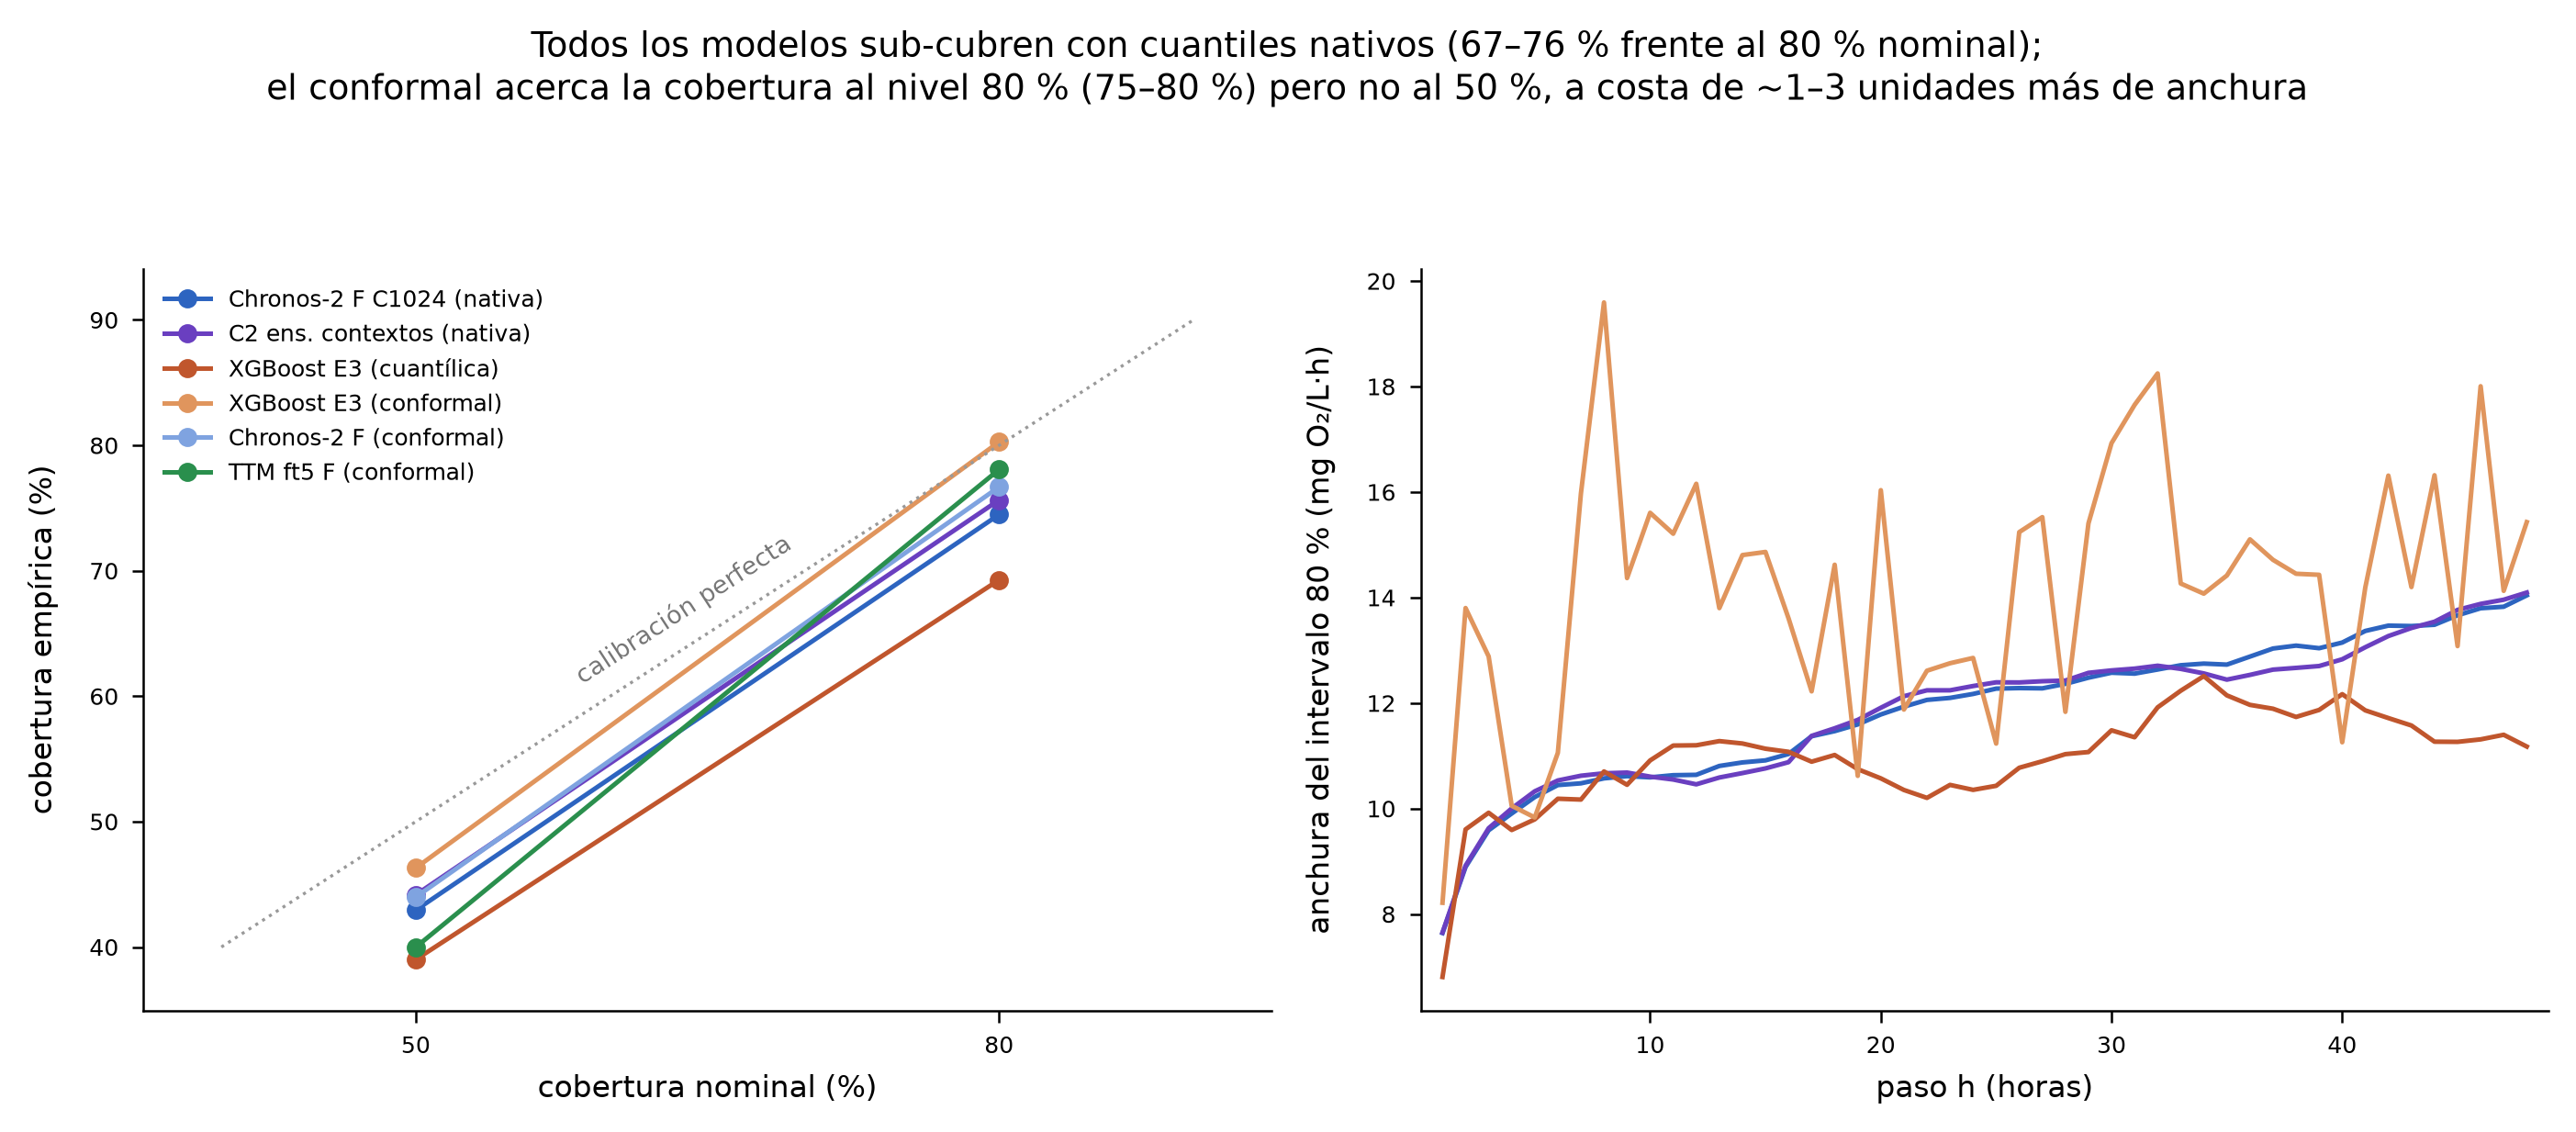

In [9]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
cob = pd.read_csv("results/cobertura.csv")
paso = pd.read_csv("results/cobertura_por_paso.csv")
PRINC = [("c2_F_C1024", "nativa", "Chronos-2 F C1024 (nativa)", "#2d64c0"),
         ("c2_ens_ctx_F", "nativa", "C2 ens. contextos (nativa)", "#6a3fc0"),
         ("xgb_E3", "nativa", "XGBoost E3 (cuantílica)", "#c0562d"),
         ("xgb_E3", "conformal", "XGBoost E3 (conformal)", "#e0955d"),
         ("c2_F_C1024", "conformal", "Chronos-2 F (conformal)", "#7fa3e0"),
         ("ttm_ft5_F", "conformal", "TTM ft5 F (conformal)", "#2a8f4d")]
fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.7))
ax = axes[0]
for cfg, src, nombre, col in PRINC:
    sub = cob[(cob.modelo==cfg) & (cob.fuente_cuantil==src) & (cob.H==48)].sort_values("nominal")
    ax.plot(sub.nominal, sub.cobertura, "o-", color=col, ms=4, label=nombre, lw=1.2)
ax.plot([40, 90], [40, 90], ":", color="#999999", lw=0.8)
ax.annotate("calibración perfecta", xy=(58, 61), fontsize=6.5, color="#777777", rotation=33)
ax.set_xlabel("cobertura nominal (%)"); ax.set_ylabel("cobertura empírica (%)", labelpad=8)
ax.set_xticks([50, 80]); ax.margins(0.08)
ax.legend(frameon=False, fontsize=6, loc="upper left")
ax = axes[1]
for cfg, src, nombre, col in PRINC[:4]:
    sub = paso[(paso.modelo==cfg) & (paso.fuente_cuantil==src) & (paso.nominal==80)]
    ax.plot(sub.h, sub.anchura_media, "-", color=col, lw=1.2)
ax.set_xlabel("paso h (horas)"); ax.set_ylabel("anchura del intervalo 80 % (mg O₂/L·h)", labelpad=8)
ax.margins(x=0.02)
fig.suptitle("Todos los modelos sub-cubren con cuantiles nativos (67–76 % frente al 80 % nominal);\n"
             "el conformal acerca la cobertura al nivel 80 % (75–80 %) pero no al 50 %, a costa de ~1–3 unidades más de anchura",
             fontsize=9, y=1.09)
fig.tight_layout()
fig.savefig("figures/fig_cobertura.png", dpi=300, bbox_inches="tight")
plt.show()

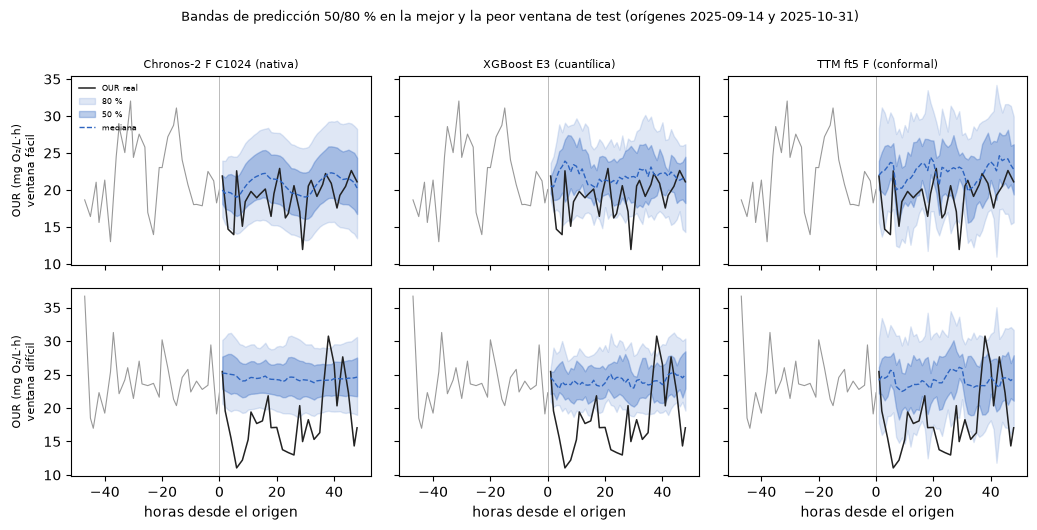

In [10]:
# ejemplo: 2 ventanas reales con bandas 50/80%
mae48 = np.abs(Y - QT["c2_F_C1024"][:, :, 2]).mean(axis=1)
w_ok, w_bad = int(np.argmin(mae48)), int(np.argmax(mae48))
TRIO = [("c2_F_C1024", "nativa", "Chronos-2 F C1024 (nativa)"),
        ("xgb_E3", "nativa", "XGBoost E3 (cuantílica)"),
        ("ttm_ft5_F", "conformal", "TTM ft5 F (conformal)")]
fig, axes = plt.subplots(2, 3, figsize=(10.5, 5.2), sharex=True, sharey="row")
for r, w in enumerate([w_ok, w_bad]):
    i = test_ilocs[w]
    hist = df['our'].iloc[i-47:i+1].to_numpy()
    xs_h = np.arange(-47, 1); xs_f = np.arange(1, 49)
    for c_, (cfg, src, nombre) in enumerate(TRIO):
        ax = axes[r, c_]
        Q = QT[cfg] if src=="nativa" else QC[cfg]
        ax.plot(xs_h, hist, "-", color="#999999", lw=0.8)
        ax.plot(xs_f, Y[w], "-", color="#222222", lw=1.1, label="OUR real")
        ax.fill_between(xs_f, Q[w,:,0], Q[w,:,4], color="#2d64c0", alpha=0.15, label="80 %")
        ax.fill_between(xs_f, Q[w,:,1], Q[w,:,3], color="#2d64c0", alpha=0.32, label="50 %")
        ax.plot(xs_f, Q[w,:,2], "--", color="#2d64c0", lw=1.0, label="mediana")
        ax.axvline(0, color="#bbbbbb", lw=0.7)
        if r == 0: ax.set_title(nombre, fontsize=8)
        if c_ == 0: ax.set_ylabel(f"OUR (mg O₂/L·h)\nventana {'fácil' if r==0 else 'difícil'}", fontsize=8)
        if r == 1: ax.set_xlabel("horas desde el origen")
axes[0, 0].legend(frameon=False, fontsize=6, loc="upper left")
fig.suptitle(f"Bandas de predicción 50/80 % en la mejor y la peor ventana de test "
             f"(orígenes {str(df.index[test_ilocs[w_ok]])[:10]} y {str(df.index[test_ilocs[w_bad]])[:10]})",
             fontsize=9, y=1.01)
fig.tight_layout()
fig.savefig("figures/fig_intervalos_ejemplo.png", dpi=300, bbox_inches="tight")
plt.show()

## 9. Conclusión

Ver `resumen_cobertura.md`: qué modelo está mejor calibrado, quién sub/sobre-cubre, cómo crecen los
intervalos con el horizonte, nativo vs conformal y la implicación operativa para la aireación.